In [1]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("nikhil1e9/loan-default")

#print("Path to dataset files:", path)

# Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier,plot_importance
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

# Data Processing

In [3]:
df = pd.read_csv("Loan_default.csv")
df.head(7)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0


In [4]:
df.shape

(255347, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df = df.drop('LoanID',axis=1)
cols = ['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']
for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


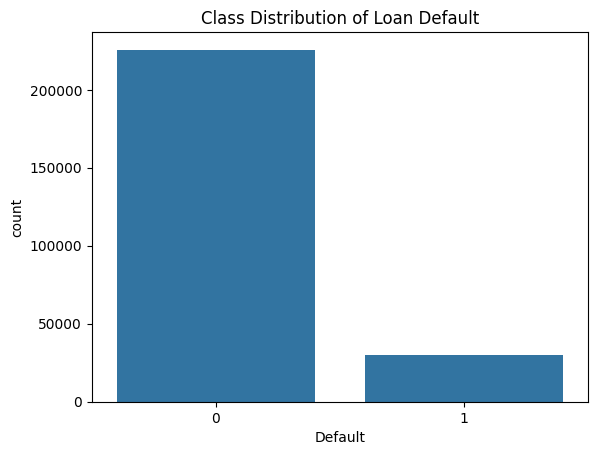

88.38717509898295 %
11.612824901017047 %


In [7]:
sns.countplot(x='Default', data=df)
plt.title('Class Distribution of Loan Default')
plt.show()
print(df['Default'].value_counts()[0]/df.shape[0]*100,"%")
print(df['Default'].value_counts()[1]/df.shape[0]*100,"%")

In [8]:
X = df.drop('Default',axis=1)
y = df['Default']

smote = SMOTE(random_state=42)
resampled_tuple = smote.fit_resample(X,y)
X_resampled, y_resampled = resampled_tuple  # Unpack the tuple
df_X_resampled = pd.DataFrame(X_resampled)
df_y_resampled = pd.DataFrame(y_resampled, columns=['Default']) # Replace 'target' with your actual target column name if you know it
df = pd.concat([df_X_resampled, df_y_resampled], axis=1)

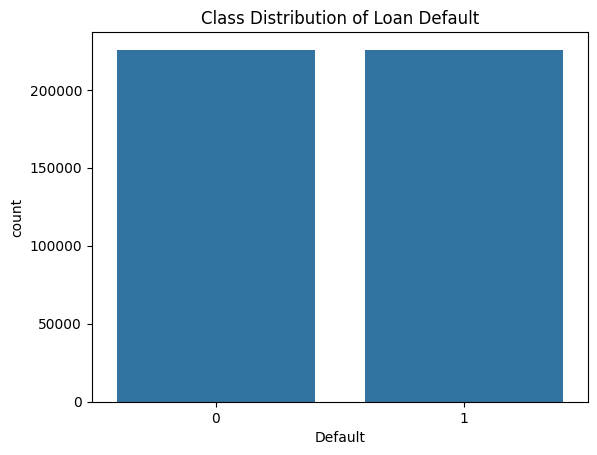

50.0 %
50.0 %


In [9]:
sns.countplot(x='Default', data=df)
plt.title('Class Distribution of Loan Default')
plt.show()
print(df['Default'].value_counts()[0]/df.shape[0]*100,"%")
print(df['Default'].value_counts()[1]/df.shape[0]*100,"%")

In [10]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [11]:
df_copy = df.copy()
to_be_scaled = ["Age","Income","LoanAmount","CreditScore","MonthsEmployed","InterestRate","LoanTerm"]
scale = StandardScaler()
df[to_be_scaled] = scale.fit_transform(df[to_be_scaled])
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,1.122196,0.202448,-1.192511,-0.321744,0.767506,4,0.112665,0.007304,0.44,0,0,0,1,1,4,1,0
1,2.049218,-0.683934,-0.148217,-0.742789,-1.252748,1,-1.580673,1.535478,0.68,2,0,1,0,0,4,1,0
2,0.409102,0.157932,-0.081079,-0.790326,-0.910859,3,1.077965,-0.756783,0.31,2,3,0,1,1,0,0,1
3,-0.589230,-1.150504,-1.274354,1.192657,-1.718960,3,-1.213404,-0.756783,0.23,1,0,1,0,0,1,0,0
4,1.407434,-1.431558,-1.778593,0.445643,-1.470313,4,-1.304408,0.771391,0.73,0,3,0,0,1,0,0,0


## EDA

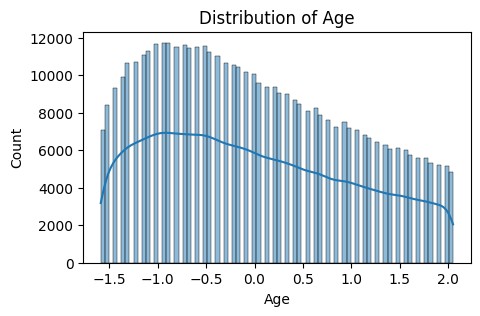

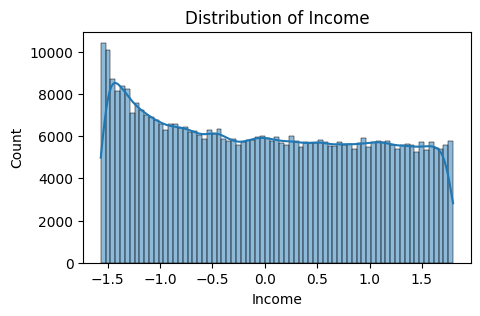

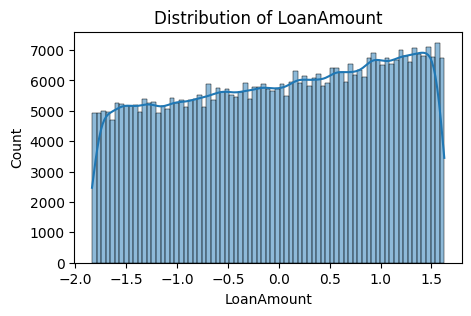

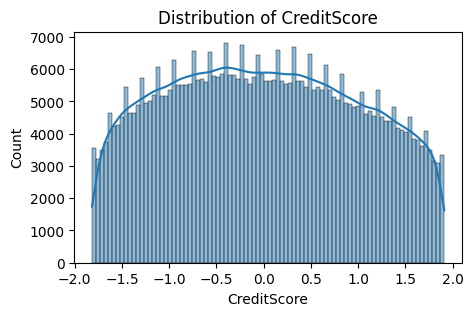

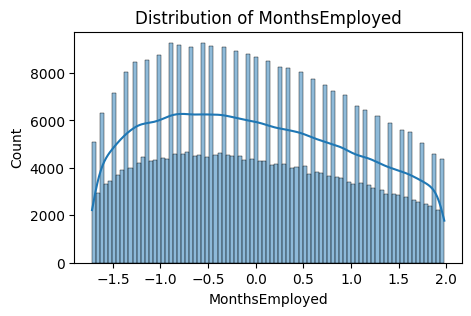

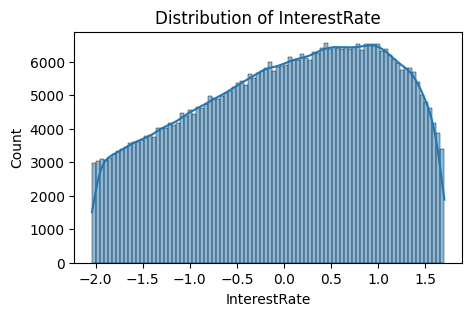

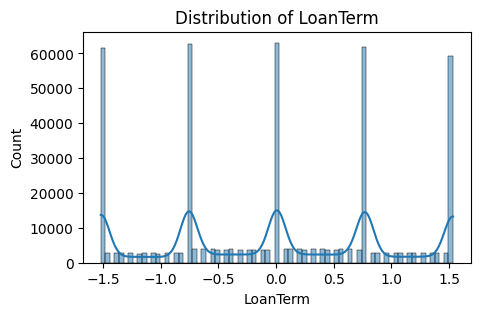

In [12]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'LoanTerm']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

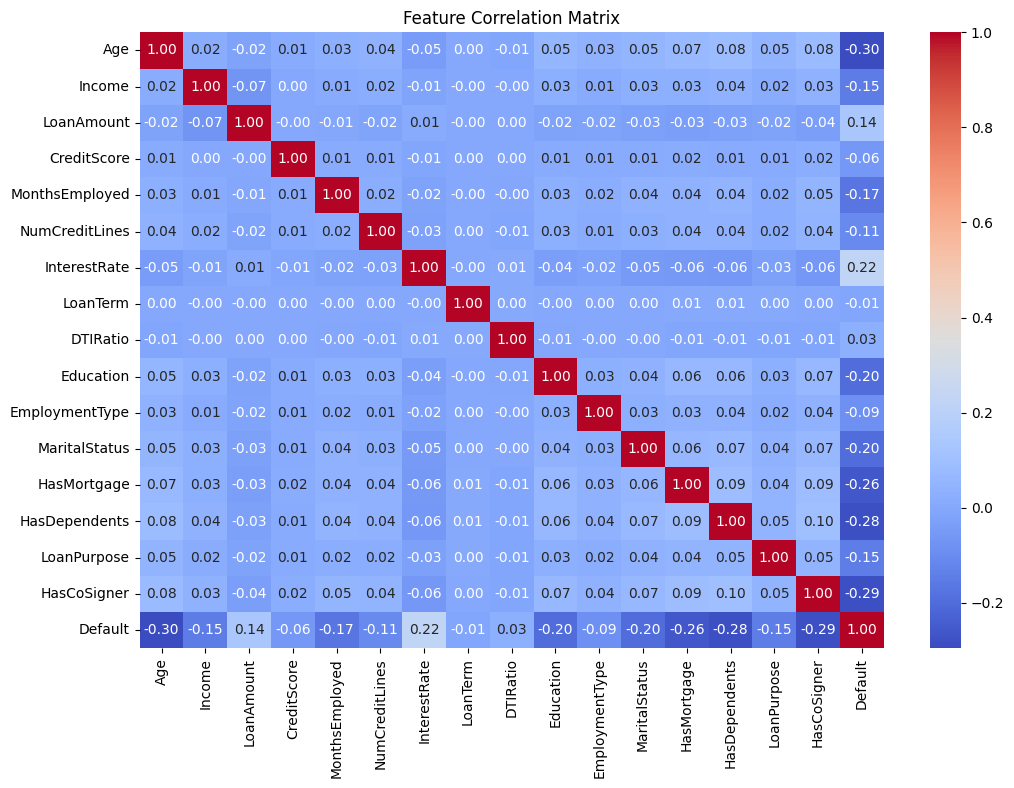

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


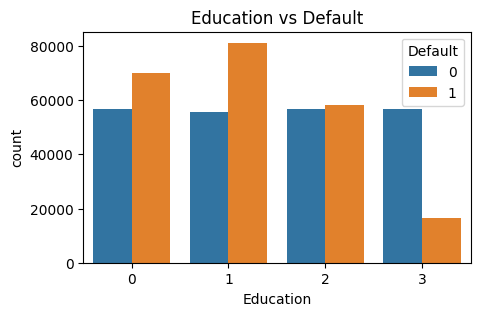

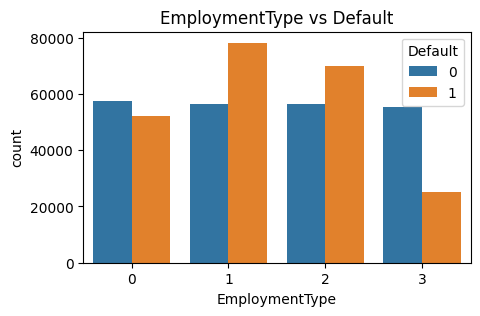

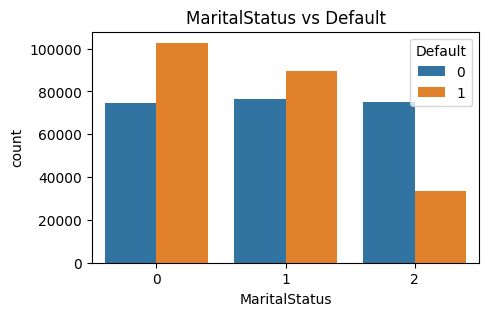

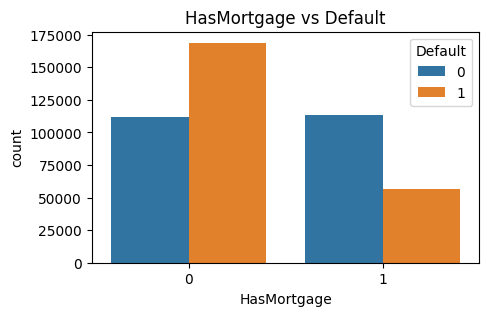

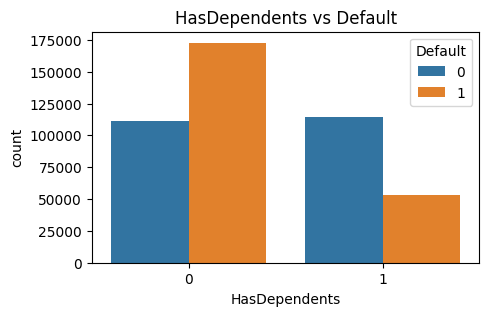

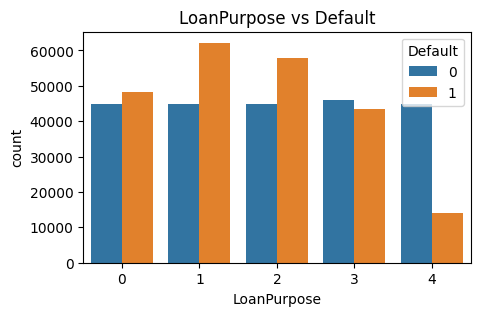

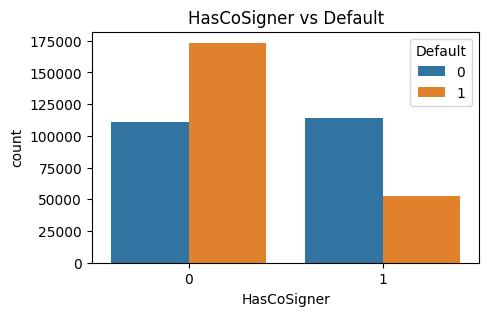

In [14]:
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, hue='Default', data=df)
    plt.title(f'{col} vs Default')
    plt.show()


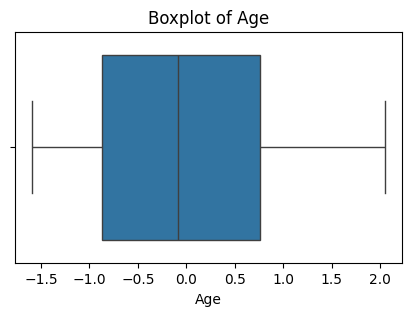

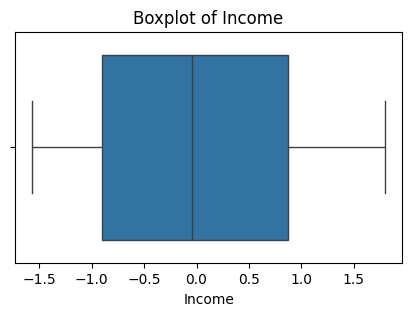

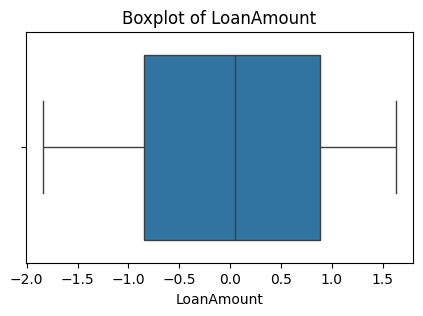

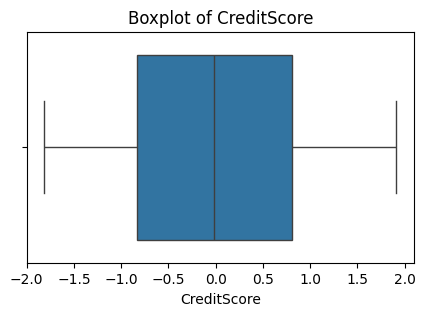

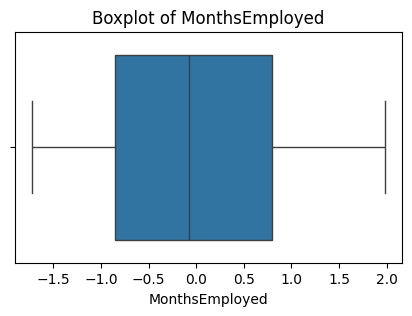

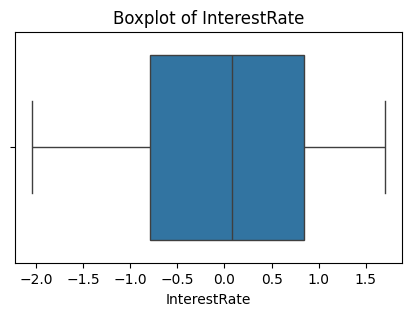

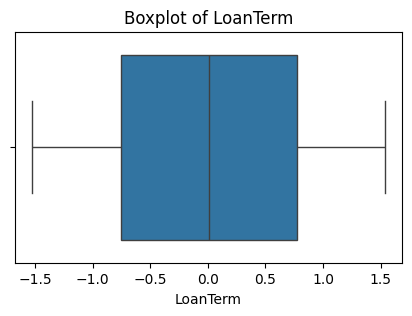

In [15]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


# Data Splitting

In [16]:
X = df.drop('Default',axis=1)
y = df['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# Model Tesing

In [17]:
logi = LogisticRegression(max_iter=5000,solver='saga',penalty='elasticnet',l1_ratio=0.5)
logi.fit(X_train,y_train)
y_pred = logi.predict(X_test)

# 5. Evaluate
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Accuracy: 0.782012330206474

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78     78959
           1       0.78      0.79      0.78     79027

    accuracy                           0.78    157986
   macro avg       0.78      0.78      0.78    157986
weighted avg       0.78      0.78      0.78    157986


Confusion Matrix:
 [[60931 18028]
 [16411 62616]]


In [18]:
r_forest = RandomForestClassifier(n_estimators=14,criterion="entropy")
r_forest.fit(X_train,y_train)
y_pred = r_forest.predict(X_test)

# 5. Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.8668869393490563

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87     78959
           1       0.90      0.83      0.86     79027

    accuracy                           0.87    157986
   macro avg       0.87      0.87      0.87    157986
weighted avg       0.87      0.87      0.87    157986


Confusion Matrix:
 [[71375  7584]
 [13446 65581]]


In [19]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_preds))

XGBoost Accuracy: 0.8986302583773246

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90     78959
           1       0.94      0.85      0.89     79027

    accuracy                           0.90    157986
   macro avg       0.90      0.90      0.90    157986
weighted avg       0.90      0.90      0.90    157986


Confusion Matrix:
 [[74533  4426]
 [11589 67438]]


In [20]:
lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgb_preds))
print("\nClassification Report:\n", classification_report(y_test, lgb_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lgb_preds))


[LightGBM] [Info] Number of positive: 146667, number of negative: 146735
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1525
[LightGBM] [Info] Number of data points in the train set: 293402, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499884 -> initscore=-0.000464
[LightGBM] [Info] Start training from score -0.000464
LightGBM Accuracy: 0.8898573291304293

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.90     78959
           1       0.93      0.84      0.88     79027

    accuracy                           0.89    157986
   macro avg       0.89      0.89      0.89    157986
weighted avg       0.89      0.89      0.89    157986


Confusion Matrix:
 [[74223  4736]
 [12665 66362]]


# Hyper Parameter Tuning

In [21]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='gpu_hist',
    predictor='gpu_predictor'
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [22]:
random_search.fit(X_train,y_train)
print("Best Parameters:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}
Accuracy: 0.910656640461813

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     78959
           1       0.95      0.87      0.91     79027

    accuracy                           0.91    157986
   macro avg       0.91      0.91      0.91    157986
weighted avg       0.91      0.91      0.91    157986


Confusion Matrix:
 [[75370  3589]
 [10526 68501]]


# Feature Engineering

In [23]:
#Interaction Features
df_copy['EstimatedDebt'] = df_copy['Income'] * df_copy['DTIRatio']

In [24]:
#Binning
df_copy['AgeGroup'] = pd.cut(df_copy['Age'], bins=[18, 30, 45, 60, 100], labels=['18-30', '30-45', '45-60', '60+'])
df_copy['CreditScoreLevel'] = pd.cut(df_copy['CreditScore'], bins=[300, 600, 700, 800, 850], labels=['Poor', 'Fair', 'Good', 'Excellent'])
le = LabelEncoder()
new_label = ['AgeGroup','CreditScoreLevel']
for col in new_label:
    df_copy[col] = le.fit_transform(df_copy[col])

In [25]:
#Domain Specific
df_copy['MonthlyLoanPayment'] = df_copy['LoanAmount'] / df_copy['LoanTerm']
df_copy['WorkLifeRatio'] = df_copy['MonthsEmployed'] / (df_copy['Age'] * 12)

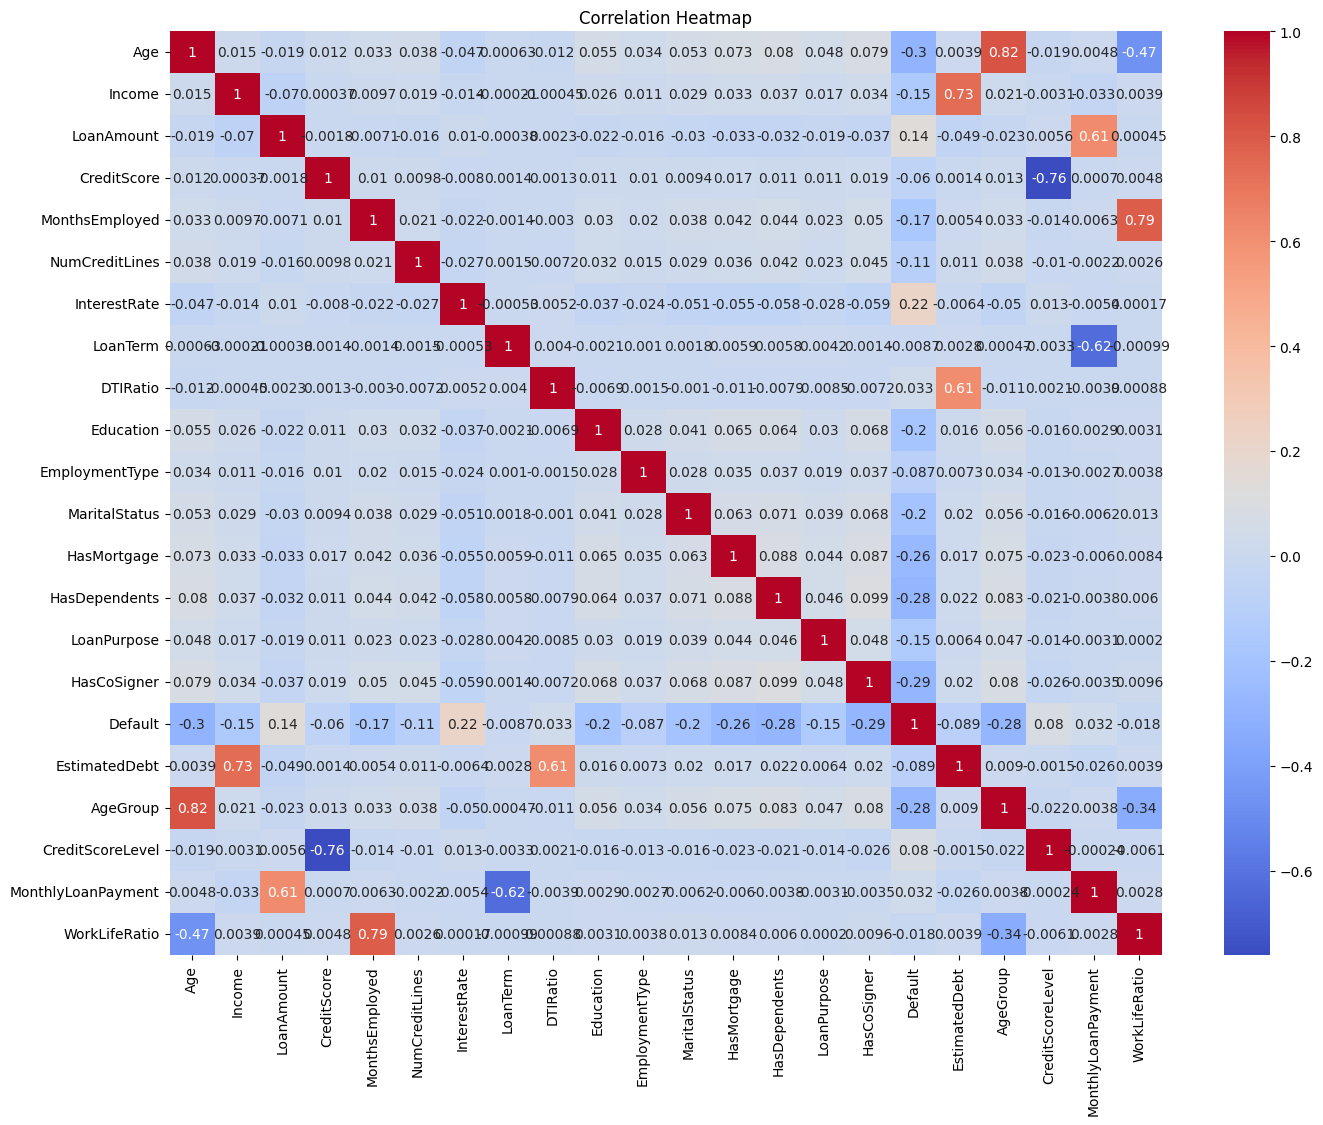

In [33]:
plt.figure(figsize=(16,12))
sns.heatmap(df_copy.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

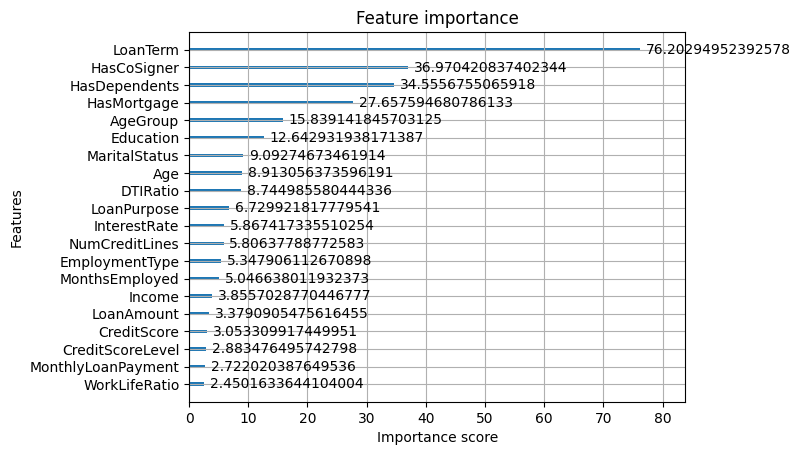

In [37]:
#Feature Importance from XGBoost
X = df_copy.drop('Default', axis=1)
y = df_copy['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

best_model.fit(X_train,y_train)
plot_importance(best_model, max_num_features=20, importance_type='gain')


In [32]:
importances = best_model.feature_importances_

# Combine with feature names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

               Feature  Importance
7             LoanTerm    0.271962
15         HasCoSigner    0.131944
13       HasDependents    0.123326
12         HasMortgage    0.098708
17            AgeGroup    0.056528
9            Education    0.045122
11       MaritalStatus    0.032451
0                  Age    0.031810
8             DTIRatio    0.031210
14         LoanPurpose    0.024018
6         InterestRate    0.020940
5       NumCreditLines    0.020722
10      EmploymentType    0.019086
4       MonthsEmployed    0.018011
1               Income    0.013761
2           LoanAmount    0.012060
3          CreditScore    0.010897
18    CreditScoreLevel    0.010291
19  MonthlyLoanPayment    0.009715
20       WorkLifeRatio    0.008744
16       EstimatedDebt    0.008694


In [34]:
important_features = [
    'LoanTerm', 'HasCoSigner', 'HasDependents', 'HasMortgage',
    'AgeGroup', 'Education', 'MaritalStatus', 'Age', 'DTIRatio',
    'LoanPurpose', 'InterestRate', 'NumCreditLines', 'EmploymentType','Default']
X_selected = df_copy[important_features]
X = X_selected.drop('Default', axis=1)
y = X_selected['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Final Model - XGBClassifier

Final Model Accuracy: 0.9120429111366215

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92     74459
           1       0.95      0.87      0.91     74500

    accuracy                           0.91    148959
   macro avg       0.91      0.91      0.91    148959
weighted avg       0.92      0.91      0.91    148959


Confusion Matrix:
 [[71053  3406]
 [ 9696 64804]]


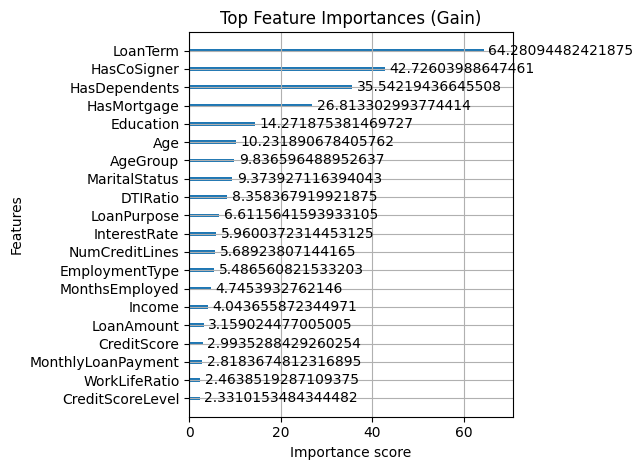

In [40]:
best_model = XGBClassifier(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.2,
    gamma=0,
    subsample=1.0,
    colsample_bytree=0.6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
best_model.fit(X_train, y_train)

# 4. Evaluation
pred = best_model.predict(X_test)
print("Final Model Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))

# 5. Feature Importance Plot
plot_importance(best_model, max_num_features=20, importance_type='gain')
plt.title("Top Feature Importances (Gain)")
plt.tight_layout()
plt.show()

# Saving Model

In [42]:
import joblib

joblib.dump(best_model, 'xgb_loan_default_model.pkl')
print("Model saved as 'xgb_loan_default_model.pkl'")

Model saved as 'xgb_loan_default_model.pkl'


In [43]:
# Load the saved model for use
loaded_model = joblib.load('xgb_loan_default_model.pkl')

pred_new = loaded_model.predict(X_test)